# Simulación de Propagación: Escenario WannaCry y Contención (Kill-Switch)

Este notebook explora la propagación de un ataque de ransomware tipo **WannaCry**, utilizando el modelo epidemiológico **SIR** sobre nuestra red modelada.

## Contexto: WannaCry (2017)
WannaCry fue un ataque global masivo. A diferencia de un ransomware tradicional que requiere que cada usuario ejecute un archivo malicioso, WannaCry actuó como un **gusano autónomo**. Utilizó el exploit *EternalBlue* para saltar de máquina en máquina aprovechando el protocolo vulnerable SMBv1 en Windows.

En términos de modelado SIR (`Susceptible -> Infectado -> Recuperado`):
- **Alta Transmisión ($\beta \approx 0.90$):** Infección casi automática si la máquina destino era vulnerable.
- **Baja Recuperación ($\gamma \approx 0.05$):** Los dispositivos infectados quedaban cifrados y no se recuperaban por sí solos. Requerían intervención humana.

## El "Kill-Switch" (Medida de Contención)
El ataque fue frenado en gran medida gracias al investigador de seguridad Marcus Hutchins. Él descubrió que antes de ejecutarse, el malware consultaba un dominio web no registrado. Si el dominio **no** respondía, procedía a cifrar. Si **sí** respondía, el malware se detenía. Marcus registró el dominio, activando el *Kill-Switch*.

Simularemos esto alterando drásticamente $\beta$ (cortando la propagación) y aumentando $\gamma$ a partir de cierto *timestep* (paso de tiempo) de la simulación.


In [1]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import networkx as nx

# Resolver la raiz del proyecto desde notebooks/ o desde la raiz del repo.
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC_DIR = PROJECT_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from pipeline_complete import NetworkGraph, SIRSimulator

# Estilo para los graficos
plt.style.use('seaborn-v0_8-whitegrid')


## 1. Construcción de la Red Vulnerable

Usaremos un grafo tipo Barabási-Albert (Scale-free network) que imita de forma realista las topologías de redes locales/empresariales, donde hay unos pocos "hub" (como servidores) altamente conectados, y muchos nodos periféricos (estaciones de trabajo).


In [2]:
# Crear el manejador del Grafo
net = NetworkGraph(name="WannaCry_Target_Network")

# Red de 300 nodos
G_sim = nx.barabasi_albert_graph(300, 3, seed=42)

for u, v in G_sim.edges():
    net.add_edge_from_flow(f"Host_{u}", f"Host_{v}")

stats = net.get_stats()
print(f"Red generada con {stats['nodes']} nodos y {stats['edges']} aristas.")

# Visualización opcional del grafo (comentado porque puede ser grande)
# fig = net.visualize(max_nodes=100)
# plt.show()


Red generada con 300 nodos y 891 aristas.


## 2. Escenario 1: WannaCry sin contención

Veamos qué sucede cuando la infección ocurre sin ninguna intervención.


Simulando Escenario Base...

🔄 Ejecutando simulación SIR...
✓ Simulación completada: 50 timesteps


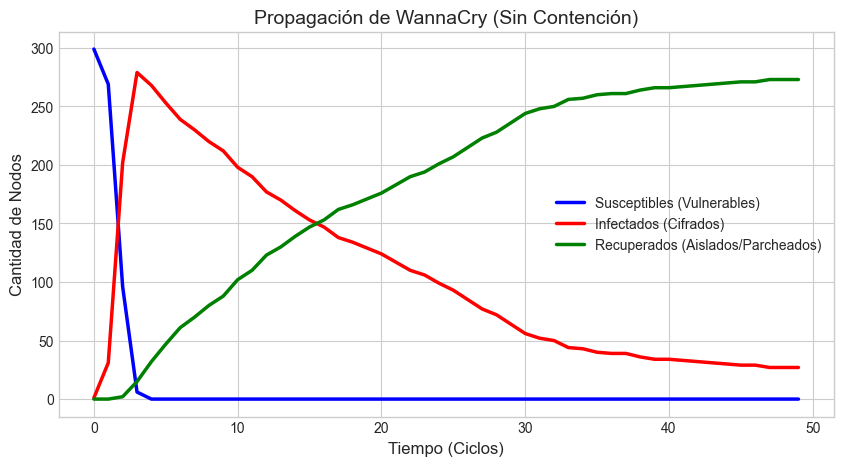

In [3]:
# Parámetros WannaCry
BETA = 0.90
GAMMA = 0.05
TIME_STEPS = 50

# Simulación Base
sir_base = SIRSimulator(net, beta=BETA, gamma=GAMMA, days=30)

print("Simulando Escenario Base...")
# Asumimos que Host_0 fue el paciente cero (el que recibió el correo de phishing o puerto expuesto)
history_base = sir_base.run(initial_infected=["Host_0"], timesteps=TIME_STEPS)

# Graficar Resultados Base
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(history_base['time'], history_base['S'], 'b-', label='Susceptibles (Vulnerables)', linewidth=2.5)
ax.plot(history_base['time'], history_base['I'], 'r-', label='Infectados (Cifrados)', linewidth=2.5)
ax.plot(history_base['time'], history_base['R'], 'g-', label='Recuperados (Aislados/Parcheados)', linewidth=2.5)

ax.set_title("Propagación de WannaCry (Sin Contención)", fontsize=14)
ax.set_xlabel("Tiempo (Ciclos)", fontsize=12)
ax.set_ylabel("Cantidad de Nodos", fontsize=12)
ax.legend()
plt.show()


## 3. Escenario 2: WannaCry con Contención (Kill-Switch activado)

Para simular esto, necesitamos extender nuestro simulador para que sea capaz de cambiar sus parámetros en tiempo real.
El *Kill-Switch* se activa en el `timestep = 15`. A partir de ahí, la transmisión ($\beta$) cae a cerca de cero, y los esfuerzos de recuperación ($\gamma$) aumentan porque ya hay una contramedida conocida y los equipos comienzan a ser aislados/reiniciados de manera segura.


In [4]:
class ContainedSIRSimulator(SIRSimulator):
    def run_with_intervention(self, initial_infected=None, timesteps=300, 
                              intervention_step=15, new_beta=0.01, new_gamma=0.2):
        print(f"\n🔄 Ejecutando simulación SIR con intervención en t={intervention_step}...")
        
        G = self.graph.G
        states = {node: 'S' for node in G.nodes()}
        
        if initial_infected is None:
            high_degree = sorted(G.degree(), key=lambda x: x[1], reverse=True)[:3]
            initial_infected = [node for node, _ in high_degree]
        
        for node in initial_infected:
            if node in states:
                states[node] = 'I'
        
        for t in range(timesteps):
            # Activar Kill-Switch
            if t == intervention_step:
                print(f"\n⚠️ [Kill-Switch Activado] Reduciendo beta de {self.beta} a {new_beta}")
                self.beta = new_beta
                self.gamma = new_gamma
            
            s_count = sum(1 for s in states.values() if s == 'S')
            i_count = sum(1 for s in states.values() if s == 'I')
            r_count = sum(1 for s in states.values() if s == 'R')
            
            self.history['S'].append(s_count)
            self.history['I'].append(i_count)
            self.history['R'].append(r_count)
            self.history['time'].append(t)
            
            new_states = states.copy()
            for node in G.nodes():
                if states[node] == 'S':
                    infected_neighbors = [n for n in G.neighbors(node) if states[n] == 'I']
                    if infected_neighbors and np.random.random() < self.beta:
                        new_states[node] = 'I'
                
                elif states[node] == 'I':
                    if np.random.random() < self.gamma:
                        new_states[node] = 'R'
            
            states = new_states
            if i_count == 0:
                break
                
        return self.history


Simulando Escenario con Contención (Kill-Switch)...

🔄 Ejecutando simulación SIR con intervención en t=10...

⚠️ [Kill-Switch Activado] Reduciendo beta de 0.9 a 0.05


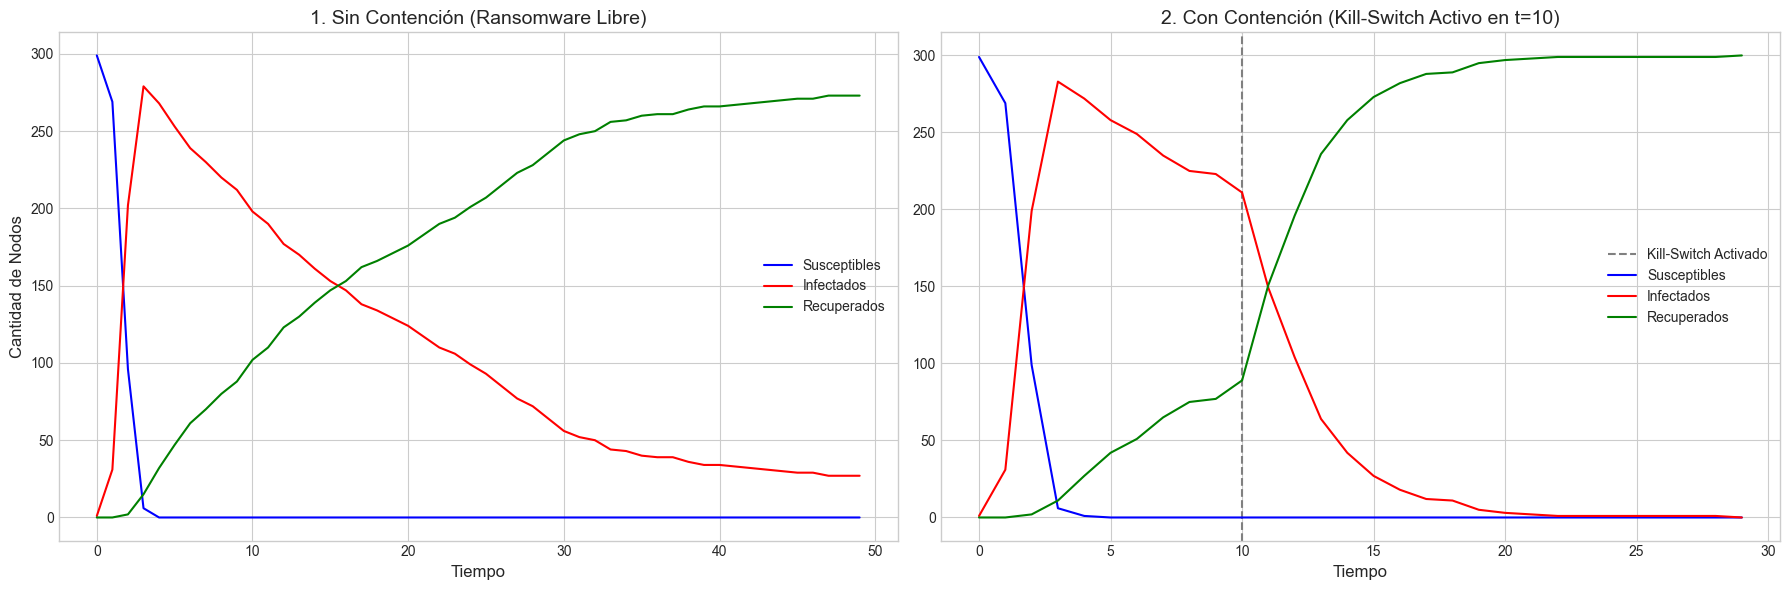

In [5]:
# Reiniciar simulador para escenario con contención
net_contained = NetworkGraph(name="WannaCry_Network")
for u, v in G_sim.edges():
    net_contained.add_edge_from_flow(f"Host_{u}", f"Host_{v}")

sir_contained = ContainedSIRSimulator(net_contained, beta=BETA, gamma=GAMMA)

print("Simulando Escenario con Contención (Kill-Switch)...")
history_contained = sir_contained.run_with_intervention(
    initial_infected=["Host_0"], 
    timesteps=TIME_STEPS,
    intervention_step=10,   # El kill switch se activa en el paso 10
    new_beta=0.05,          # Transmisión se detiene abruptamente
    new_gamma=0.30          # Se acelera el parcheo y aislamiento
)

# Comparativa visual
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Gráfico 1: Sin contención
axes[0].plot(history_base['time'], history_base['S'], 'b-', label='Susceptibles')
axes[0].plot(history_base['time'], history_base['I'], 'r-', label='Infectados')
axes[0].plot(history_base['time'], history_base['R'], 'g-', label='Recuperados')
axes[0].set_title("1. Sin Contención (Ransomware Libre)", fontsize=14)
axes[0].set_xlabel("Tiempo", fontsize=12)
axes[0].set_ylabel("Cantidad de Nodos", fontsize=12)
axes[0].legend()

# Gráfico 2: Con contención
axes[1].axvline(x=10, color='gray', linestyle='--', label='Kill-Switch Activado')
axes[1].plot(history_contained['time'], history_contained['S'], 'b-', label='Susceptibles')
axes[1].plot(history_contained['time'], history_contained['I'], 'r-', label='Infectados')
axes[1].plot(history_contained['time'], history_contained['R'], 'g-', label='Recuperados')
axes[1].set_title("2. Con Contención (Kill-Switch Activo en t=10)", fontsize=14)
axes[1].set_xlabel("Tiempo", fontsize=12)
axes[1].legend()

plt.tight_layout()
plt.show()


## 4. Visualización Interactiva (Timeline de Nodos)

Para poder visualizar gráficamente cómo el virus salta de nodo en nodo, necesitamos guardar el estado individual de cada máquina en cada paso de tiempo y luego usar `ipywidgets` para navegar por el tiempo.


In [6]:
class InteractiveSIRSimulator(SIRSimulator):
    def __init__(self, graph, beta=0.4, gamma=0.1, days=30):
        super().__init__(graph, beta, gamma, days)
        self.node_states_history = []
        
    def run_interactive(self, initial_infected=None, timesteps=300, 
                        intervention_step=None, new_beta=None, new_gamma=None):
        G = self.graph.G
        
        # Usar Sets para operaciones super rápidas O(1)
        S = set(G.nodes())
        I = set()
        R = set()
        
        self.node_states_history = []
        
        if initial_infected is None:
            high_degree = sorted(G.degree(), key=lambda x: x[1], reverse=True)[:3]
            initial_infected = [node for node, _ in high_degree]
        
        for node in initial_infected:
            if node in S:
                S.remove(node)
                I.add(node)
                
        for t in range(timesteps):
            # Guardar snapshot rapidísimo (sin usar deepcopy)
            states_snapshot = {n: 'S' for n in S}
            states_snapshot.update({n: 'I' for n in I})
            states_snapshot.update({n: 'R' for n in R})
            self.node_states_history.append(states_snapshot)
            
            # Guardar conteos
            self.history['S'].append(len(S))
            self.history['I'].append(len(I))
            self.history['R'].append(len(R))
            self.history['time'].append(t)
            
            if intervention_step and t == intervention_step:
                self.beta = new_beta
                self.gamma = new_gamma
            
            if not I:
                self.node_states_history.append(states_snapshot)
                break
                
            new_I = set()
            new_R = set()
            
            # Iterar SOLO sobre nodos infectados (es muchísimo más rápido)
            for node in I:
                # Recuperación
                if np.random.random() < self.gamma:
                    new_R.add(node)
                
                # Propagación: solo ver vecinos de este nodo infectado que sean S
                for neighbor in G.neighbors(node):
                    if neighbor in S and np.random.random() < self.beta:
                        new_I.add(neighbor)
            
            # Actualizar sets
            S -= new_I
            I = (I | new_I) - new_R
            R |= new_R
                
        return self.history, self.node_states_history


In [7]:
print("Corriendo simulaciones con rastreo de nodos...")

# Escenario 1: Base
sim_base_int = InteractiveSIRSimulator(net, beta=BETA, gamma=GAMMA)
hist_base_int, states_base = sim_base_int.run_interactive(initial_infected=["Host_0"], timesteps=TIME_STEPS)

# Escenario 2: Contención
sim_cont_int = InteractiveSIRSimulator(net_contained, beta=BETA, gamma=GAMMA)
hist_cont_int, states_cont = sim_cont_int.run_interactive(
    initial_infected=["Host_0"], 
    timesteps=TIME_STEPS,
    intervention_step=10, 
    new_beta=0.05, 
    new_gamma=0.30
)
print("¡Simulaciones completadas!")

Corriendo simulaciones con rastreo de nodos...
¡Simulaciones completadas!


In [8]:
from ipywidgets import Play, IntSlider, Dropdown, VBox, HBox, interactive_output, jslink
from IPython.display import display
import matplotlib.pyplot as plt
import networkx as nx
import matplotlib.patches as mpatches

# Pre-calcular posiciones usando nx.spring_layout para que los nodos no salten en cada frame
pos = nx.spring_layout(G_sim, k=0.15, seed=42)

def plot_network_and_curve(timestep, scenario):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8), gridspec_kw={'width_ratios': [1.2, 1]})
    
    if scenario == 'Base (Sin Contención)':
        states = states_base
        hist = hist_base_int
        title_net = f"Red: WannaCry sin contención - Hora: {timestep*2}h"
        title_curve = "Curva de Infección (Sin Contención)"
    else:
        states = states_cont
        hist = hist_cont_int
        title_net = f"Red: WannaCry con Kill-Switch - Hora: {timestep*2}h"
        title_curve = "Curva de Infección (Kill-Switch Activo en 20h)"
        
    # --- GRÁFICO 1: RED ---
    t = min(timestep, len(states) - 1)
    current_states = states[t]
    
    color_map = {'S': 'lightblue', 'I': '#e74c3c', 'R': '#2ecc71'}
    node_colors = [color_map[current_states[f"Host_{node}"]] for node in G_sim.nodes()]
    
    nx.draw_networkx_nodes(G_sim, pos, node_color=node_colors, node_size=80, ax=ax1, alpha=0.9, edgecolors='white')
    nx.draw_networkx_edges(G_sim, pos, ax=ax1, alpha=0.15)
    
    ax1.set_title(title_net, fontsize=16, fontweight='bold', pad=20)
    ax1.axis('off')
    
    s_patch = mpatches.Patch(color='lightblue', label='Susceptible (Vulnerable)')
    i_patch = mpatches.Patch(color='#e74c3c', label='Infectado (Cifrado)')
    r_patch = mpatches.Patch(color='#2ecc71', label='Recuperado (Aislado/Parcheado)')
    ax1.legend(handles=[s_patch, i_patch, r_patch], loc='upper left', fontsize=11, frameon=True)
    
    # --- GRÁFICO 2: CURVAS SIR ---
    # Convertir timesteps a horas reales simuladas (2 horas por timestep)
    horas = [h * 2 for h in hist['time']]
    
    ax2.plot(horas, hist['S'], color='lightblue', label='Susceptibles', linewidth=2.5)
    ax2.plot(horas, hist['I'], color='#e74c3c', label='Infectados', linewidth=2.5)
    ax2.plot(horas, hist['R'], color='#2ecc71', label='Recuperados', linewidth=2.5)
    
    # Pico de infección
    max_infeccion = max(hist['I'])
    idx_max = hist['I'].index(max_infeccion)
    hora_pico = horas[idx_max]
    dia_pico = hora_pico / 24.0
    
    ax2.axvline(x=hora_pico, color='darkred', linestyle=':', linewidth=2, label=f'Pico: {max_infeccion} nodos (Día {dia_pico:.1f})')
    ax2.plot(hora_pico, max_infeccion, 'ro', markersize=8)
    
    if scenario != 'Base (Sin Contención)':
        ax2.axvline(x=10*2, color='gray', linestyle='--', linewidth=2, label='Kill-Switch (Día 0.8)')
        
    # Línea de tiempo actual
    hora_actual = min(timestep * 2, max(horas))
    ax2.axvline(x=hora_actual, color='black', linestyle='-', alpha=0.8, linewidth=2, label='Progreso Actual')
    
    ax2.set_title(title_curve, fontsize=16, fontweight='bold')
    ax2.set_xlabel("Tiempo (Horas simuladas)", fontsize=12)
    ax2.set_ylabel("Cantidad de Nodos (Dispositivos)", fontsize=12)
    ax2.grid(True, alpha=0.3)
    ax2.legend(loc='upper right', fontsize=11)
    
    # Ajustar límites
    ax2.set_xlim(0, max(horas) + 2)
    ax2.set_ylim(0, max(hist['S']) + 10)
    
    plt.tight_layout()
    plt.show()

# Crear controles interactivos y botón Play para reproducción automática
max_t = max(len(states_base), len(states_cont)) - 1

play = Play(value=0, min=0, max=max_t, step=1, interval=400, description="Reproducir")
slider = IntSlider(min=0, max=max_t, step=1, description='Paso:', layout={'width': '400px'})
jslink((play, 'value'), (slider, 'value'))

dropdown = Dropdown(options=['Base (Sin Contención)', 'Con Contención (Kill-Switch)'], 
                    value='Con Contención (Kill-Switch)', description='Escenario:')

# Mostrar interfaz
ui = VBox([HBox([play, slider]), dropdown])
out = interactive_output(plot_network_and_curve, {'timestep': slider, 'scenario': dropdown})
display(ui, out)

Output()

## 5. Simulacion SIR informada por el PCAP de WannaCry

En las secciones anteriores usamos parametros teoricos para representar un gusano tipo WannaCry. Ahora usamos los resultados procesados desde el PCAP local `wannaCry_15052017.pcap.gz` para estimar la intensidad de comunicacion SMB/445 y calibrar la tasa de transmision.

La idea metodologica es: el PCAP no representa toda la epidemia global, pero si captura comportamiento observado de la muestra. Por eso lo usamos para parametrizar la simulacion sobre una red sintetica empresarial de mayor escala.


In [9]:
import json
import pandas as pd

from wannacry_pcap_sir_simulation import (
    beta_from_pcap,
    load_analysis,
    make_enterprise_like_graph,
    plot_scenarios,
    run_dynamic_sir,
)

analysis_path = PROJECT_ROOT / 'data' / 'processed' / 'wannacry_pcap_analysis.json'
analysis = load_analysis(analysis_path)

beta_pcap = beta_from_pcap(analysis)
gamma_base = 0.04
nodes = 300
steps = 80
seed = 42
kill_switch_step = 1

print('Resumen PCAP procesado')
print(f"Paquetes analizados: {analysis['packets']:,}")
print(f"Paquetes SMB/445: {analysis['smb_packets']:,}")
print(f"Participacion SMB: {analysis['smb_packet_share']:.4%}")
print(f"Tasa SMB observada: {analysis['observed_smb_packet_rate_per_second']:.2f} paquetes/s")
print(f"Beta calibrado desde PCAP: {beta_pcap}")


Resumen PCAP procesado
Paquetes analizados: 836,056
Paquetes SMB/445: 835,831
Participacion SMB: 99.9731%
Tasa SMB observada: 2244.43 paquetes/s
Beta calibrado desde PCAP: 0.9223


In [10]:
G_pcap = make_enterprise_like_graph(nodes, seed)
patient_zero = [max(G_pcap.degree, key=lambda item: item[1])[0]]

sir_no_containment = run_dynamic_sir(
    G_pcap,
    beta=beta_pcap,
    gamma=gamma_base,
    steps=steps,
    initial_infected=patient_zero,
    seed=seed,
)
sir_no_containment['scenario'] = 'sin_contencion'

sir_kill_switch = run_dynamic_sir(
    G_pcap,
    beta=beta_pcap,
    gamma=gamma_base,
    steps=steps,
    initial_infected=patient_zero,
    kill_switch_step=kill_switch_step,
    contained_beta=0.08,
    contained_gamma=0.22,
    seed=seed,
)
sir_kill_switch['scenario'] = 'kill_switch'

pcap_sir_results = pd.concat([sir_no_containment, sir_kill_switch], ignore_index=True)
pcap_sir_results.to_csv(PROJECT_ROOT / 'data' / 'processed' / 'wannacry_pcap_sir_results.csv', index=False)

summary_rows = []
for scenario, group in pcap_sir_results.groupby('scenario'):
    peak = group.loc[group['I'].idxmax()]
    final = group.iloc[-1]
    summary_rows.append({
        'scenario': scenario,
        'peak_step': int(peak['step']),
        'peak_infected': int(peak['I']),
        'final_susceptible': int(final['S']),
        'final_infected': int(final['I']),
        'final_recovered': int(final['R']),
    })

pd.DataFrame(summary_rows)


,scenario,peak_step,peak_infected,final_susceptible,final_infected,final_recovered
0,kill_switch,6,67,110,0,190
1,sin_contencion,3,290,0,20,280


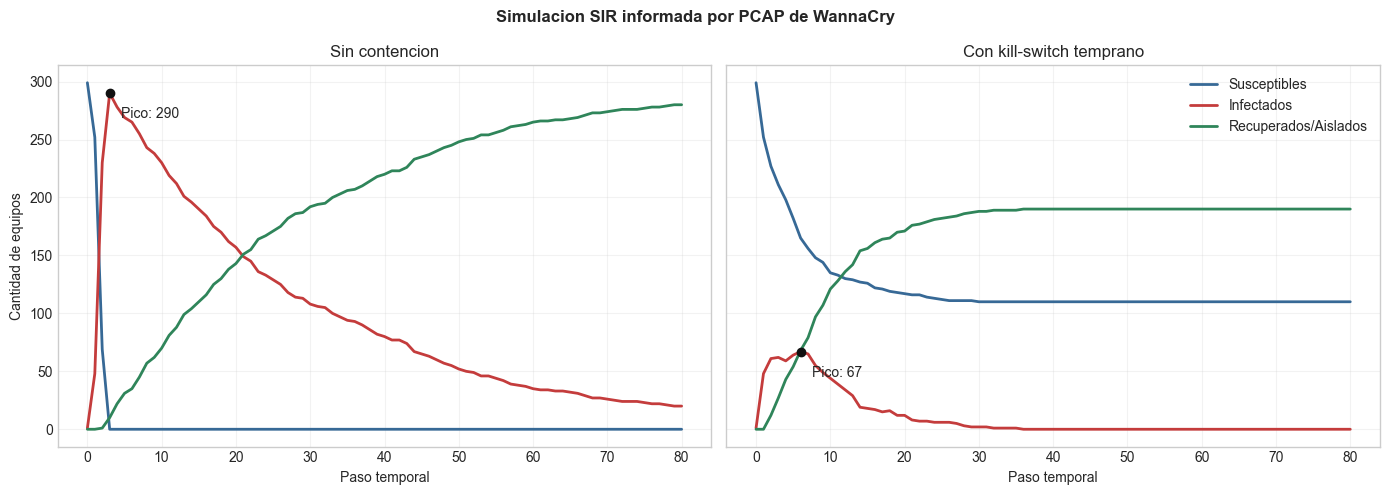

Figura guardada en: C:\Users\Arnold's\Documents\Repositorios Machine Learning\Proyecto final Healtech\reports\figures\wannacry_pcap_informed_sir.png


In [11]:
figure_path = plot_scenarios(
    sir_no_containment,
    sir_kill_switch,
    PROJECT_ROOT / 'reports' / 'figures',
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
colors = {'S': '#376996', 'I': '#c43c3c', 'R': '#2f855a'}
labels = {'S': 'Susceptibles', 'I': 'Infectados', 'R': 'Recuperados/Aislados'}
for ax, (title, df) in zip(axes, [('Sin contencion', sir_no_containment), ('Con kill-switch temprano', sir_kill_switch)]):
    for state in ['S', 'I', 'R']:
        ax.plot(df['step'], df[state], label=labels[state], color=colors[state], linewidth=2)
    peak = df.loc[df['I'].idxmax()]
    ax.scatter([peak['step']], [peak['I']], color='#111111', zorder=5)
    ax.annotate(f"Pico: {int(peak['I'])}", xy=(peak['step'], peak['I']), xytext=(8, -18), textcoords='offset points')
    ax.set_title(title)
    ax.set_xlabel('Paso temporal')
    ax.grid(alpha=0.25)
axes[0].set_ylabel('Cantidad de equipos')
axes[1].legend(loc='upper right')
fig.suptitle('Simulacion SIR informada por PCAP de WannaCry', fontweight='bold')
fig.tight_layout()
plt.show()

print(f'Figura guardada en: {figure_path}')


## 6. Grafo geografico observado desde Hybrid Analysis

Ademas del PCAP, la pagina local de Hybrid Analysis aporta una tabla de `Contacted Hosts`. Esa tabla permite construir un grafo geografico observado: el proceso `mssecsvc.exe` contacta IPs distribuidas por paises.

Las coordenadas son aproximadas por centroide de pais. Esto sirve para visualizar distribucion global, no para afirmar la ubicacion exacta de cada IP.


,country,hosts,latitude,longitude,has_coordinates
0,United States,142,37.0902,-95.7129,True
1,China,29,35.8617,104.1954,True
2,Japan,18,36.2048,138.2529,True
3,Germany,9,51.1657,10.4515,True
4,United Kingdom,8,55.3781,-3.4360,True
5,France,8,46.2276,2.2137,True
6,Canada,7,56.1304,-106.3468,True
7,Indonesia,6,-0.7893,113.9213,True
8,Italy,6,41.8719,12.5674,True
9,Australia,6,-25.2744,133.7751,True


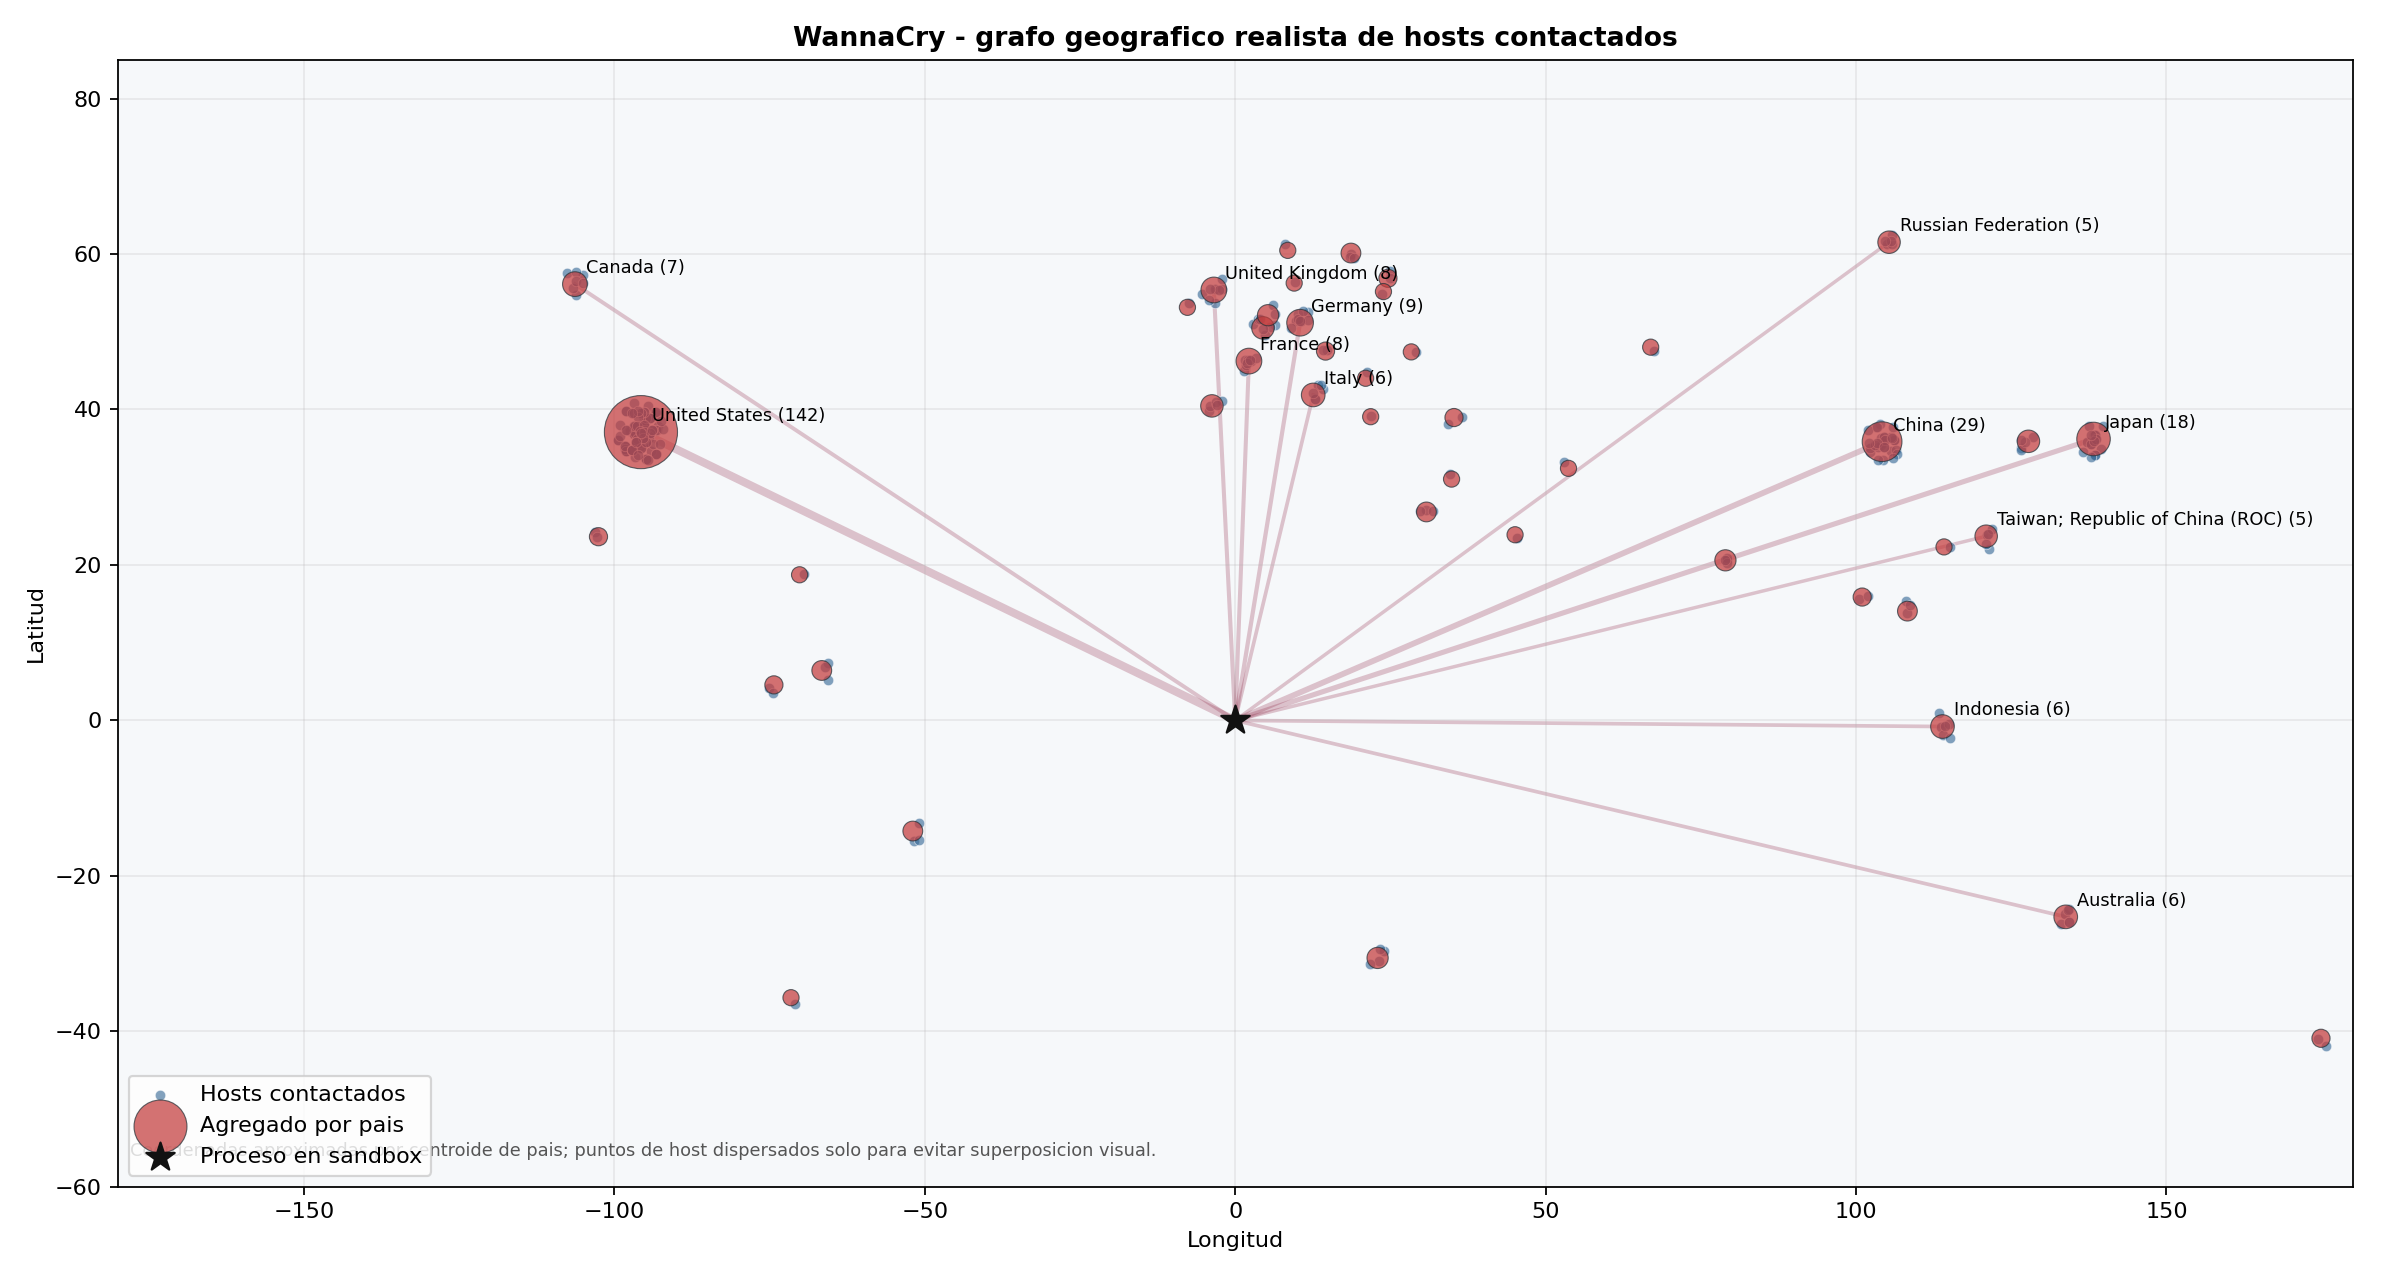

In [12]:
from IPython.display import Image, display

countries_path = PROJECT_ROOT / 'data' / 'processed' / 'hybrid_analysis_contacted_countries.csv'
geo_figure = PROJECT_ROOT / 'reports' / 'figures' / 'wannacry_realistic_geo_graph.png'

countries_geo = pd.read_csv(countries_path)
display(countries_geo.head(12))

if geo_figure.exists():
    display(Image(filename=str(geo_figure)))
else:
    print('No se encontro la figura geografica. Ejecuta src/graph/build_wannacry_geo_graph.py')


## 7. Simulacion geografica interactiva de propagacion

Esta visualizacion usa la tabla de paises contactados por la muestra de Hybrid Analysis y la intensidad SMB observada en el PCAP para construir una animacion didactica de propagacion.

Importante: no representa una geolocalizacion exacta de infecciones reales. Es una simulacion informada por artefactos reales: el PCAP aporta intensidad de propagacion y Hybrid Analysis aporta distribucion geografica de hosts contactados.


In [13]:
from matplotlib.patches import Polygon
from IPython.display import display
import ipywidgets as widgets

# Fondo estilizado de continentes. Es liviano y evita depender de librerias GIS externas.
CONTINENTS = {
    'Norteamerica': [(-168, 15), (-150, 55), (-125, 72), (-95, 62), (-75, 48), (-58, 22), (-88, 8), (-120, 15)],
    'Sudamerica': [(-82, 12), (-55, 8), (-38, -10), (-48, -35), (-66, -55), (-80, -25)],
    'Europa': [(-12, 36), (5, 58), (32, 62), (45, 45), (25, 35), (5, 37)],
    'Africa': [(-18, 35), (18, 36), (45, 10), (34, -34), (12, -35), (-8, -5)],
    'Asia': [(35, 5), (55, 55), (100, 72), (150, 55), (145, 20), (115, 2), (85, 8), (68, -8)],
    'Oceania': [(110, -10), (155, -12), (170, -35), (135, -45), (112, -32)],
    'Groenlandia': [(-52, 60), (-22, 72), (-38, 84), (-68, 78)],
}

def draw_continent_background(ax):
    ax.set_facecolor('#dfeff4')
    for points in CONTINENTS.values():
        ax.add_patch(Polygon(points, closed=True, facecolor='#d8d2bd', edgecolor='#8d8a7a', linewidth=0.8, alpha=0.88, zorder=0))
    ax.set_xlim(-180, 180)
    ax.set_ylim(-60, 85)
    ax.set_xlabel('Longitud')
    ax.set_ylabel('Latitud')
    ax.grid(alpha=0.18, color='white', linewidth=0.8)

# Guardar el fondo para reutilizarlo en el informe si se necesita.
bg_path = PROJECT_ROOT / 'reports' / 'figures' / 'world_continents_background.png'
fig, ax = plt.subplots(figsize=(12, 6))
draw_continent_background(ax)
ax.set_title('Fondo geografico estilizado de continentes')
fig.tight_layout()
fig.savefig(bg_path, dpi=150)
plt.close(fig)
print(f'Fondo guardado en: {bg_path}')


Fondo guardado en: C:\Users\Arnold's\Documents\Repositorios Machine Learning\Proyecto final Healtech\reports\figures\world_continents_background.png


In [14]:
countries_sim = pd.read_csv(PROJECT_ROOT / 'data' / 'processed' / 'hybrid_analysis_contacted_countries.csv')
countries_sim['latitude'] = pd.to_numeric(countries_sim['latitude'], errors='coerce')
countries_sim['longitude'] = pd.to_numeric(countries_sim['longitude'], errors='coerce')
countries_sim['hosts'] = pd.to_numeric(countries_sim['hosts'], errors='coerce').fillna(0).astype(int)
countries_sim = countries_sim.dropna(subset=['latitude', 'longitude']).copy()
countries_sim = countries_sim.sort_values('hosts', ascending=False).reset_index(drop=True)

# Parametrizacion temporal: paises con mayor cantidad de hosts observados aparecen antes
# y luego crecen con una curva logistica modulada por beta calibrado desde el PCAP.
max_step_geo = 36
countries_sim['activation_step'] = np.clip((countries_sim.index * 0.75).round().astype(int), 0, max_step_geo - 8)
countries_sim.loc[countries_sim['country'].eq('United States'), 'activation_step'] = 0
countries_sim.loc[countries_sim['country'].eq('China'), 'activation_step'] = 2
countries_sim.loc[countries_sim['country'].eq('Japan'), 'activation_step'] = 4

def simulated_infected_hosts(row, step, containment=False):
    if step < row.activation_step:
        return 0
    local_t = step - row.activation_step
    growth = beta_pcap * (0.9 if not containment else 0.42)
    midpoint = 4.2 if not containment else 7.5
    cap = row.hosts if not containment else max(1, int(row.hosts * 0.55))
    value = cap / (1 + np.exp(-growth * (local_t - midpoint)))
    return int(round(min(cap, value)))

geo_timeline = []
for step in range(max_step_geo + 1):
    for row in countries_sim.itertuples(index=False):
        geo_timeline.append({
            'step': step,
            'country': row.country,
            'latitude': row.latitude,
            'longitude': row.longitude,
            'observed_hosts': row.hosts,
            'activation_step': row.activation_step,
            'infected_no_containment': simulated_infected_hosts(row, step, containment=False),
            'infected_containment': simulated_infected_hosts(row, step, containment=True),
        })
geo_timeline = pd.DataFrame(geo_timeline)
geo_timeline.to_csv(PROJECT_ROOT / 'data' / 'processed' / 'wannacry_geo_timeline_simulation.csv', index=False)

display(countries_sim[['country', 'hosts', 'activation_step', 'latitude', 'longitude']].head(12))


,country,hosts,activation_step,latitude,longitude
0,United States,142,0,37.0902,-95.7129
1,China,29,2,35.8617,104.1954
2,Japan,18,4,36.2048,138.2529
3,Germany,9,2,51.1657,10.4515
4,United Kingdom,8,3,55.3781,-3.4360
5,France,8,4,46.2276,2.2137
6,Canada,7,4,56.1304,-106.3468
7,Indonesia,6,5,-0.7893,113.9213
8,Italy,6,6,41.8719,12.5674
9,Australia,6,7,-25.2744,133.7751


In [15]:
def plot_geo_step(step=0, scenario='Sin contencion'):
    metric = 'infected_no_containment' if scenario == 'Sin contencion' else 'infected_containment'
    current = geo_timeline[geo_timeline['step'] == step].copy()
    active = current[current[metric] > 0].copy()

    fig, (ax_map, ax_curve) = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={'width_ratios': [2.25, 1]})
    draw_continent_background(ax_map)

    if not active.empty:
        sizes = 45 + (active[metric].astype(float) ** 0.82) * 24
        colors = active[metric] / max(1, current['observed_hosts'].max())
        scatter = ax_map.scatter(
            active['longitude'],
            active['latitude'],
            s=sizes,
            c=colors,
            cmap='Reds',
            vmin=0,
            vmax=1,
            edgecolors='#263238',
            linewidths=0.6,
            alpha=0.82,
            zorder=4,
        )
        for row in active.sort_values(metric, ascending=False).head(8).itertuples(index=False):
            ax_map.annotate(
                f'{row.country} ({int(getattr(row, metric))})',
                (row.longitude, row.latitude),
                xytext=(5, 5),
                textcoords='offset points',
                fontsize=8,
            )
        cbar = fig.colorbar(scatter, ax=ax_map, fraction=0.026, pad=0.02)
        cbar.set_label('Intensidad relativa')

    total_by_step = geo_timeline.groupby('step')[[metric]].sum().reset_index()
    ax_curve.plot(total_by_step['step'], total_by_step[metric], color='#c43c3c', linewidth=2.5)
    ax_curve.axvline(step, color='#111111', linestyle='--', linewidth=1.4)
    ax_curve.scatter([step], [total_by_step.loc[total_by_step['step'].eq(step), metric].iloc[0]], color='#111111', zorder=5)
    ax_curve.set_title('Evolucion temporal')
    ax_curve.set_xlabel('Paso temporal')
    ax_curve.set_ylabel('Hosts simulados comprometidos')
    ax_curve.grid(alpha=0.25)

    total = int(active[metric].sum()) if not active.empty else 0
    countries_active = int(active['country'].nunique()) if not active.empty else 0
    ax_map.set_title(f'WannaCry geografico - {scenario} | paso {step} | hosts: {total} | paises: {countries_active}', fontweight='bold')
    fig.tight_layout()
    plt.show()

play = widgets.Play(value=0, min=0, max=max_step_geo, step=1, interval=450, description='Play')
step_slider = widgets.IntSlider(value=0, min=0, max=max_step_geo, step=1, description='Tiempo')
scenario_dropdown = widgets.Dropdown(options=['Sin contencion', 'Con contencion'], value='Sin contencion', description='Escenario')
widgets.jslink((play, 'value'), (step_slider, 'value'))
out = widgets.interactive_output(plot_geo_step, {'step': step_slider, 'scenario': scenario_dropdown})
display(widgets.VBox([widgets.HBox([play, step_slider, scenario_dropdown]), out]))
